# Dataset 1 Analysis

In [9]:
import pandas as pd

df_Lung_Cancer = pd.read_csv("Lung Cancer.csv")
print(df_Lung_Cancer)

    GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0        M   69        1               2        2              1   
1        M   74        2               1        1              1   
2        F   59        1               1        1              2   
3        M   63        2               2        2              1   
4        F   63        1               2        1              1   
..     ...  ...      ...             ...      ...            ...   
304      F   56        1               1        1              2   
305      M   70        2               1        1              1   
306      M   58        2               1        1              1   
307      M   67        2               1        2              1   
308      M   62        1               1        1              2   

     CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  \
0                  1         2         1         2                  2   
1                  2         2       

DATASET 1: Lung Cancer Dataset
First 5 rows
   GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0       1   69        1               2        2              1   
1       1   74        2               1        1              1   
2       0   59        1               1        1              2   
3       1   63        2               2        2              1   
4       0   63        1               2        1              1   

   CHRONIC DISEASE  FATIGUE  ALLERGY  WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1        2        1         2                  2         2   
1                2        2        2         1                  1         1   
2                1        2        1         2                  1         2   
3                1        1        1         1                  2         1   
4                1        1        1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN  LUNG_CANCER  
0    

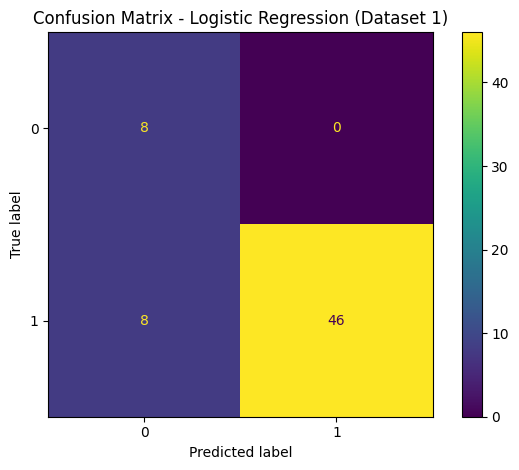


Logistic Regression Results: Dataset 1 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.8643
Mean Precision: 0.9670
Mean Recall   : 0.8741
Mean F1-score : 0.9181

Feature Importance Ranking (Absolute Coefficient Magnitude)
                  Feature  Importance
0   SWALLOWING DIFFICULTY    1.232686
1         CHRONIC DISEASE    1.227037
2                 FATIGUE    1.198142
3                COUGHING    1.155293
4                 ALLERGY    1.032629
5           PEER_PRESSURE    0.908162
6       ALCOHOL CONSUMING    0.840043
7          YELLOW_FINGERS    0.807060
8                 ANXIETY    0.759817
9                 SMOKING    0.684689
10               WHEEZING    0.518987
11                    AGE    0.285934
12             CHEST PAIN    0.260665
13                 GENDER    0.259269
14    SHORTNESS OF BREATH    0.171108


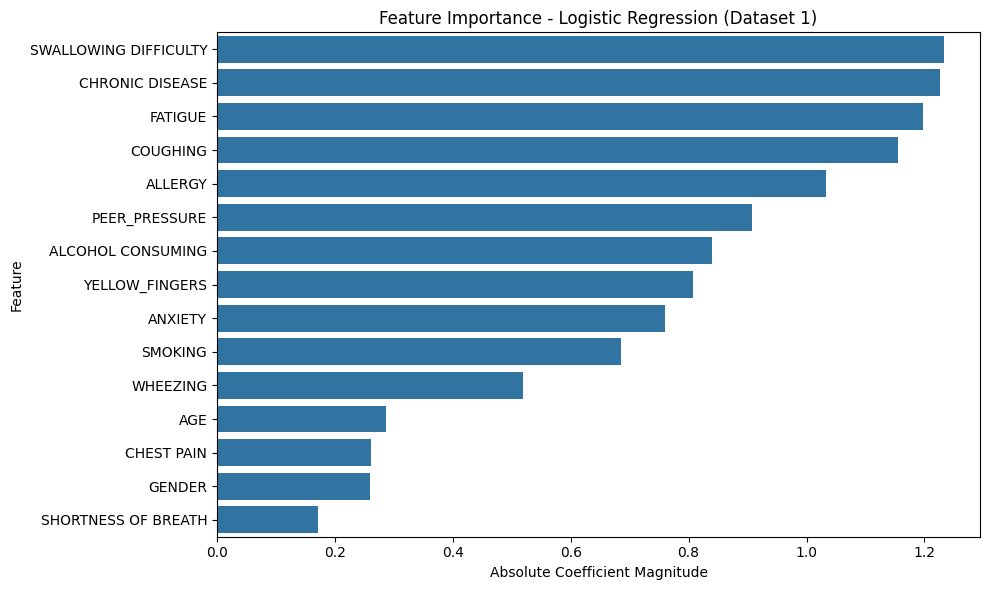


Individual Feature Results (5-Fold CV)
              Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0                 FATIGUE             1  0.676097   0.908446  0.700000   
1     SHORTNESS OF BREATH             1  0.624643   0.890742  0.651852   
2                COUGHING             1  0.640666   0.946563  0.625926   
3                 ALLERGY             1  0.650714   0.970422  0.618519   
4       ALCOHOL CONSUMING             1  0.637758   0.958112  0.611111   
5          YELLOW_FINGERS             1  0.611740   0.926095  0.603704   
6                WHEEZING             1  0.624326   0.949043  0.603704   
7              CHEST PAIN             1  0.605182   0.930917  0.592593   
8                 SMOKING             1  0.566526   0.887825  0.574074   
9                     AGE             1  0.543733   0.890618  0.544444   
10          PEER_PRESSURE             1  0.563458   0.938938  0.537037   
11                 GENDER             1  0.540561   0.897891  0.537037  

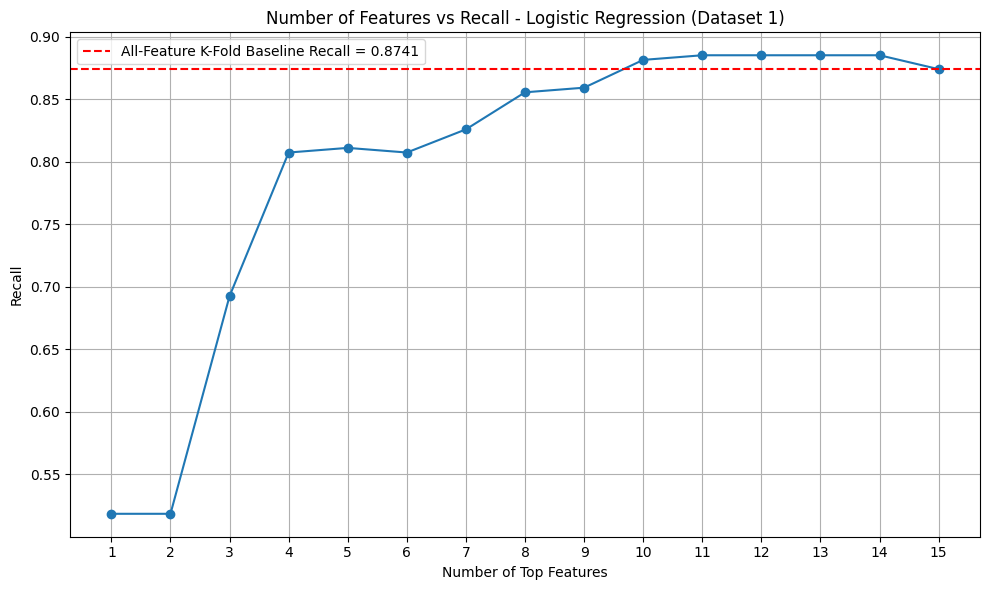

In [10]:
# LOGISTIC REGRESSION
import sklearn
from sklearn import linear_model
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

print("DATASET 1: Lung Cancer Dataset")

pd.set_option('display.max_columns', None)

df1_lr = df_Lung_Cancer.copy()

# Clean column names
df1_lr.columns = df1_lr.columns.str.strip()

# Encode categorical variables
df1_lr['GENDER'] = LabelEncoder().fit_transform(df1_lr['GENDER'])
df1_lr['LUNG_CANCER'] = LabelEncoder().fit_transform(df1_lr['LUNG_CANCER'])

print("First 5 rows")
print(df1_lr.head())

print("\nColumn names:")
print(df1_lr.columns.tolist())

print("\nDataset info:")
df1_lr.info()

print("\nMissing values:")
print(df1_lr.isnull().sum())

# Fill missing values if any exist
for col in df1_lr.columns:
    if df1_lr[col].dtype == "object":
        df1_lr[col] = df1_lr[col].fillna(df1_lr[col].mode()[0])
    else:
        df1_lr[col] = df1_lr[col].fillna(df1_lr[col].median())

print("\nMissing values after filling:")
print(df1_lr.isnull().sum())

# Define features and target
X1 = df1_lr.drop(columns=['LUNG_CANCER'])
y1 = df1_lr['LUNG_CANCER']

# Scale features for Logistic Regression
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)

# Logistic Regression model
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# 80/20 train-test split baseline
X_train, X_test, y_train, y_test = train_test_split(
    X1_scaled,
    y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

model.fit(X_train, y_train)

# Predictions
y_pred1 = model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred1))

# Evaluation
accuracy_1 = accuracy_score(y_test, y_pred1)
precision_1 = precision_score(y_test, y_pred1, zero_division=0)
recall_1 = recall_score(y_test, y_pred1, zero_division=0)
f1_1 = f1_score(y_test, y_pred1, zero_division=0)

print("\nLogistic Regression Results: Dataset 1 (80/20 Split Baseline)")
print(f"Accuracy : {accuracy_1:.4f}")
print(f"Precision: {precision_1:.4f}")
print(f"Recall   : {recall_1:.4f}")
print(f"F1-score : {f1_1:.4f}")

cm1 = confusion_matrix(y_test, y_pred1)

print("\nConfusion Matrix:")
print(cm1)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm1,
    display_labels=model.classes_
)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression (Dataset 1)")
plt.tight_layout()
plt.show()

# BASELINE K-FOLD METRICS

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

baseline_cv_results = cross_validate(
    baseline_model,
    X1_scaled,
    y1,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nLogistic Regression Results: Dataset 1 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

# FEATURE IMPORTANCE
lr_model_full = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

lr_model_full.fit(X1_scaled, y1)

feature_importance_df = pd.DataFrame({
    "Feature": X1.columns,
    "Importance": np.abs(lr_model_full.coef_[0])
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking (Absolute Coefficient Magnitude)")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Logistic Regression (Dataset 1)")
plt.xlabel("Absolute Coefficient Magnitude")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS

individual_feature_results = []

for feature in feature_importance_df["Feature"]:
    X_single = X1[[feature]]

    scaler_single = StandardScaler()
    X_single_scaled = scaler_single.fit_transform(X_single)

    single_model = LogisticRegression(
        random_state=42,
        class_weight="balanced",
        max_iter=1000
    )

    single_cv_results = cross_validate(
        single_model,
        X_single_scaled,
        y1,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    individual_feature_results.append({
        "Feature_Set": feature,
        "Num_Features": 1,
        "Accuracy": single_cv_results["test_accuracy"].mean(),
        "Precision": single_cv_results["test_precision"].mean(),
        "Recall": single_cv_results["test_recall"].mean(),
        "F1-score": single_cv_results["test_f1"].mean()
    })

individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS

ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range(1, len(ranked_features) + 1):
    selected_features = ranked_features[:k]
    X_topk = X1[selected_features]

    scaler_topk = StandardScaler()
    X_topk_scaled = scaler_topk.fit_transform(X_topk)

    topk_model = LogisticRegression(
        random_state=42,
        class_weight="balanced",
        max_iter=1000
    )

    topk_cv_results = cross_validate(
        topk_model,
        X_topk_scaled,
        y1,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_features),
        "Accuracy": topk_cv_results["test_accuracy"].mean(),
        "Precision": topk_cv_results["test_precision"].mean(),
        "Recall": topk_cv_results["test_recall"].mean(),
        "F1-score": topk_cv_results["test_f1"].mean()
    })

topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON

baseline_row = pd.DataFrame([{
    "Num_Features": X1.shape[1],
    "Features_Used": "All Features (Official Baseline)",
    "Accuracy": baseline_accuracy_cv,
    "Precision": baseline_precision_cv,
    "Recall": baseline_recall_cv,
    "F1-score": baseline_f1_cv
}])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_row)

# PLOT: NUMBER OF FEATURES VS RECALL

plt.figure(figsize=(10, 6))
plt.plot(topk_results_df["Num_Features"], topk_results_df["Recall"], marker="o")
plt.axhline(
    y=baseline_recall_cv,
    color="red",
    linestyle="--",
    label=f"All-Feature K-Fold Baseline Recall = {baseline_recall_cv:.4f}"
)
plt.title("Number of Features vs Recall - Logistic Regression (Dataset 1)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# LOGISTIC REGRESSION RESULTS FOR FINAL COMPARISON
lr_summary = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_1,
    "Precision": precision_1,
    "Recall": recall_1,
    "F1-score": f1_1,
    "CV Accuracy": baseline_accuracy_cv,
    "CV Precision": baseline_precision_cv,
    "CV Recall": baseline_recall_cv,
    "CV F1-score": baseline_f1_cv
}

cm_lr = cm1.copy()
topk_lr_results_df = topk_results_df.copy()

DATASET 1: Lung Cancer Dataset
First 5 rows:
  GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0      M   69        1               2        2              1   
1      M   74        2               1        1              1   
2      F   59        1               1        1              2   
3      M   63        2               2        2              1   
4      F   63        1               2        1              1   

   CHRONIC DISEASE  FATIGUE  ALLERGY  WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1        2        1         2                  2         2   
1                2        2        2         1                  1         1   
2                1        2        1         2                  1         2   
3                1        1        1         1                  2         1   
4                1        1        1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN LUNG_CANCER  
0          

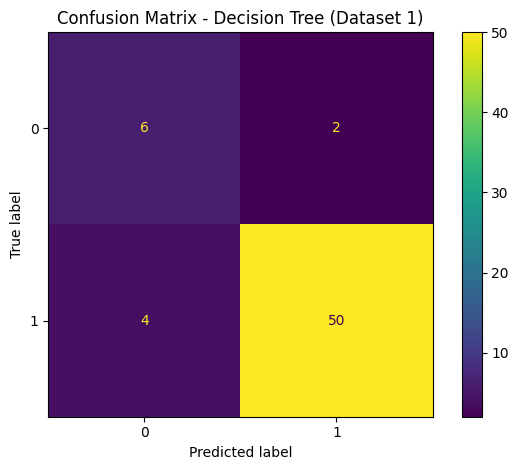


Decision Tree Results: Dataset 1 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.8902
Mean Precision: 0.9304
Mean Recall   : 0.9444
Mean F1-score : 0.9369

Feature Importance Ranking
                  Feature    Importance
0                 ALLERGY  2.585597e-01
1                     AGE  1.741287e-01
2   SWALLOWING DIFFICULTY  1.232183e-01
3           PEER_PRESSURE  8.911700e-02
4                 ANXIETY  6.521498e-02
5       ALCOHOL CONSUMING  5.238701e-02
6                 SMOKING  4.051639e-02
7                 FATIGUE  3.558585e-02
8                COUGHING  3.503602e-02
9                  GENDER  3.207988e-02
10         YELLOW_FINGERS  2.416295e-02
11               WHEEZING  2.406570e-02
12    SHORTNESS OF BREATH  2.346519e-02
13        CHRONIC DISEASE  2.246235e-02
14             CHEST PAIN  4.221499e-17


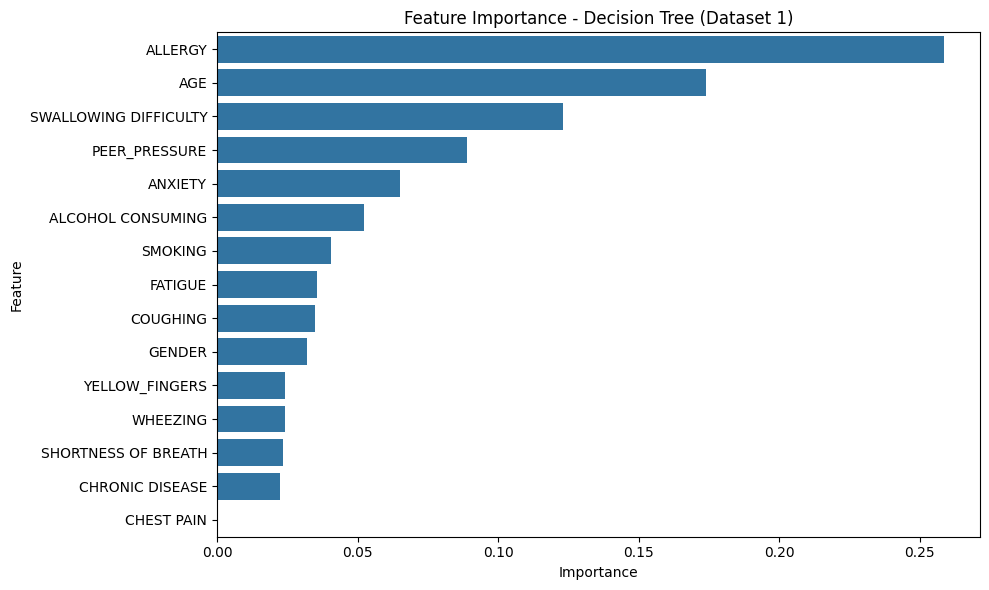


Individual Feature Results (5-Fold CV)
              Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0                 FATIGUE             1  0.676097   0.908446  0.700000   
1                     AGE             1  0.647488   0.904488  0.666667   
2     SHORTNESS OF BREATH             1  0.624643   0.890742  0.651852   
3                COUGHING             1  0.640666   0.946563  0.625926   
4                 ALLERGY             1  0.650714   0.970422  0.618519   
5       ALCOHOL CONSUMING             1  0.637758   0.958112  0.611111   
6          YELLOW_FINGERS             1  0.611740   0.926095  0.603704   
7                WHEEZING             1  0.624326   0.949043  0.603704   
8              CHEST PAIN             1  0.605182   0.930917  0.592593   
9                 SMOKING             1  0.566526   0.887825  0.574074   
10          PEER_PRESSURE             1  0.563458   0.938938  0.537037   
11                 GENDER             1  0.540561   0.897891  0.537037  

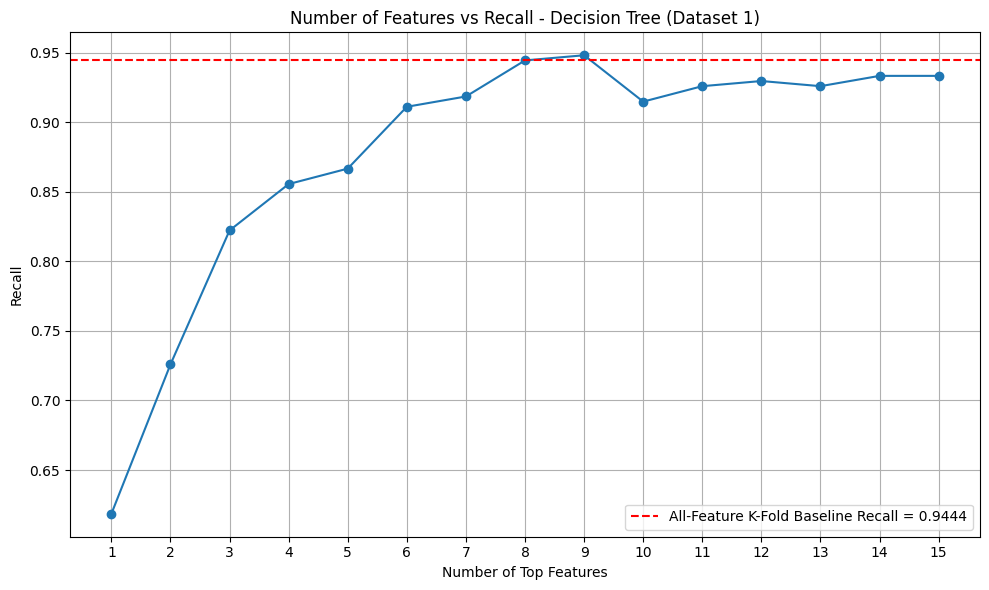

In [11]:
# DECISION TREE
import sklearn
from sklearn import tree
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

print("DATASET 1: Lung Cancer Dataset")

pd.set_option('display.max_columns', None)

df1_dt = df_Lung_Cancer.copy()

# Clean column names
df1_dt.columns = df1_dt.columns.str.strip()

print("First 5 rows:")
print(df1_dt.head())

print("\nColumn names:")
print(df1_dt.columns.tolist())

print("\nDataset info:")
df1_dt.info()

print("\nMissing values:")
print(df1_dt.isnull().sum())

# FILL MISSING VALUES
for col in df1_dt.columns:
    if df1_dt[col].dtype == "object":
        df1_dt[col] = df1_dt[col].fillna(df1_dt[col].mode()[0])
    else:
        df1_dt[col] = df1_dt[col].fillna(df1_dt[col].median())

print("\nMissing values after filling:")
print(df1_dt.isnull().sum())

# ENCODING
df1_dt['GENDER'] = LabelEncoder().fit_transform(df1_dt['GENDER'])
df1_dt['LUNG_CANCER'] = LabelEncoder().fit_transform(df1_dt['LUNG_CANCER'])

# DEFINE TARGET AND FEATURES
X1 = df1_dt.drop(columns=['LUNG_CANCER'])
y1 = df1_dt['LUNG_CANCER']

print("\nClass distribution:")
print(y1.value_counts())

print("\nClass distribution (proportion):")
print(y1.value_counts(normalize=True))

# BASELINE MODEL
model = tree.DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

# 80/20 TRAIN-TEST SPLIT BASELINE
X_train, X_test, y_train, y_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

model.fit(X_train, y_train)

# PREDICTIONS
y_pred1 = model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred1, zero_division=0))

# EVALUATION
accuracy_1 = accuracy_score(y_test, y_pred1)
precision_1 = precision_score(y_test, y_pred1, zero_division=0)
recall_1 = recall_score(y_test, y_pred1, zero_division=0)
f1_1 = f1_score(y_test, y_pred1, zero_division=0)

print("\nDecision Tree Results: Dataset 1 (80/20 Split Baseline)")
print(f"Accuracy : {accuracy_1:.4f}")
print(f"Precision: {precision_1:.4f}")
print(f"Recall   : {recall_1:.4f}")
print(f"F1-score : {f1_1:.4f}")

cm1 = confusion_matrix(y_test, y_pred1)

print("\nConfusion Matrix:")
print(cm1)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm1,
    display_labels=model.classes_
)
disp.plot()
plt.title("Confusion Matrix - Decision Tree (Dataset 1)")
plt.tight_layout()
plt.show()

# BASELINE K-FOLD METRICS
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = tree.DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

baseline_cv_results = cross_validate(
    baseline_model,
    X1,
    y1,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nDecision Tree Results: Dataset 1 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

# FEATURE IMPORTANCE
dt_model_full = tree.DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model_full.fit(X1, y1)

feature_importance_df = pd.DataFrame({
    "Feature": X1.columns,
    "Importance": dt_model_full.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Decision Tree (Dataset 1)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS
individual_feature_results = []

for feature in feature_importance_df["Feature"]:
    X_single = X1[[feature]]

    single_model = tree.DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )

    single_cv_results = cross_validate(
        single_model,
        X_single,
        y1,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    individual_feature_results.append({
        "Feature_Set": feature,
        "Num_Features": 1,
        "Accuracy": single_cv_results["test_accuracy"].mean(),
        "Precision": single_cv_results["test_precision"].mean(),
        "Recall": single_cv_results["test_recall"].mean(),
        "F1-score": single_cv_results["test_f1"].mean()
    })

individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS
ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range(1, len(ranked_features) + 1):
    selected_features = ranked_features[:k]
    X_topk = X1[selected_features]

    topk_model = tree.DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )

    topk_cv_results = cross_validate(
        topk_model,
        X_topk,
        y1,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_features),
        "Accuracy": topk_cv_results["test_accuracy"].mean(),
        "Precision": topk_cv_results["test_precision"].mean(),
        "Recall": topk_cv_results["test_recall"].mean(),
        "F1-score": topk_cv_results["test_f1"].mean()
    })

topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_row = pd.DataFrame([{
    "Num_Features": X1.shape[1],
    "Features_Used": "All Features (Official Baseline)",
    "Accuracy": baseline_accuracy_cv,
    "Precision": baseline_precision_cv,
    "Recall": baseline_recall_cv,
    "F1-score": baseline_f1_cv
}])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_row)

# PLOT: NUMBER OF FEATURES VS RECALL
plt.figure(figsize=(10, 6))
plt.plot(topk_results_df["Num_Features"], topk_results_df["Recall"], marker="o")
plt.axhline(
    y=baseline_recall_cv,
    color="red",
    linestyle="--",
    label=f"All-Feature K-Fold Baseline Recall = {baseline_recall_cv:.4f}"
)
plt.title("Number of Features vs Recall - Decision Tree (Dataset 1)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# DECISION TREE RESULTS FOR FINAL COMPARISON
dt_summary = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_1,
    "Precision": precision_1,
    "Recall": recall_1,
    "F1-score": f1_1,
    "CV Accuracy": baseline_accuracy_cv,
    "CV Precision": baseline_precision_cv,
    "CV Recall": baseline_recall_cv,
    "CV F1-score": baseline_f1_cv
}

cm_dt = cm1.copy()
topk_dt_results_df = topk_results_df.copy()

DATASET 1: Lung Cancer Dataset - Random Forest
First 5 rows:
  GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0      M   69        1               2        2              1   
1      M   74        2               1        1              1   
2      F   59        1               1        1              2   
3      M   63        2               2        2              1   
4      F   63        1               2        1              1   

   CHRONIC DISEASE  FATIGUE  ALLERGY  WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1        2        1         2                  2         2   
1                2        2        2         1                  1         1   
2                1        2        1         2                  1         2   
3                1        1        1         1                  2         1   
4                1        1        1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN LUNG_CANC

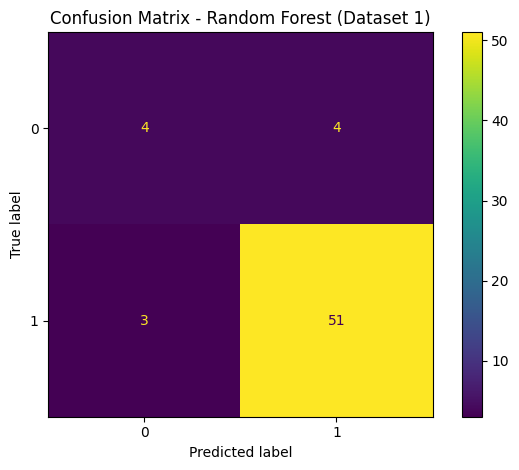


Random Forest Results: Dataset 1 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.9063
Mean Precision: 0.9358
Mean Recall   : 0.9593
Mean F1-score : 0.9469

Feature Importance Ranking
                  Feature  Importance
0                     AGE    0.146451
1                 ALLERGY    0.136953
2       ALCOHOL CONSUMING    0.096429
3   SWALLOWING DIFFICULTY    0.089078
4                 FATIGUE    0.071515
5                COUGHING    0.063552
6           PEER_PRESSURE    0.062383
7                WHEEZING    0.061783
8          YELLOW_FINGERS    0.053601
9                 ANXIETY    0.049492
10             CHEST PAIN    0.040387
11        CHRONIC DISEASE    0.039683
12    SHORTNESS OF BREATH    0.036909
13                 GENDER    0.025925
14                SMOKING    0.025860


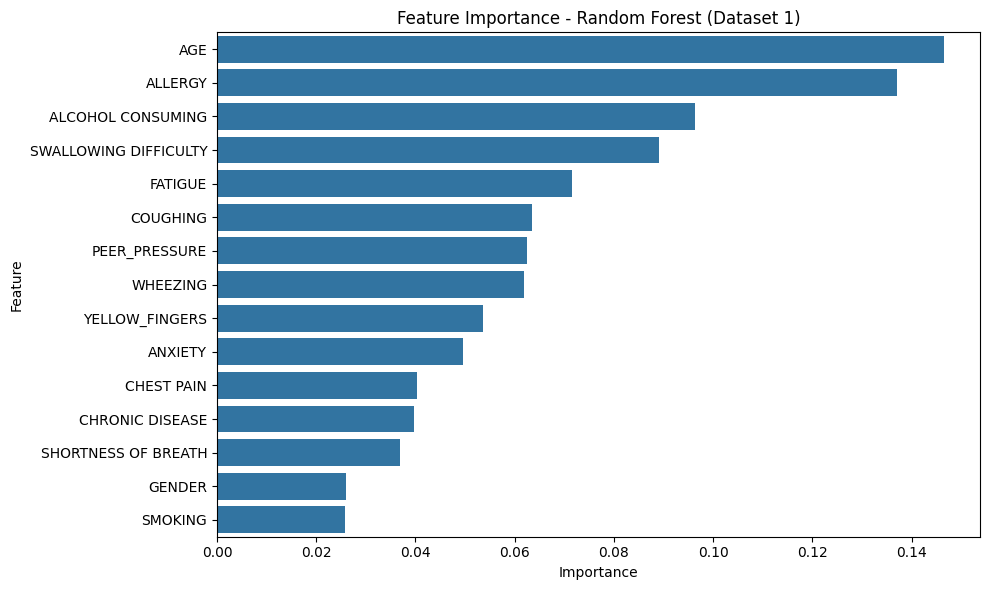


Individual Feature Results (5-Fold CV)
              Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0                     AGE             1  0.682972   0.902633  0.714815   
1                 FATIGUE             1  0.676097   0.908446  0.700000   
2     SHORTNESS OF BREATH             1  0.624643   0.890742  0.651852   
3                  GENDER             1  0.602856   0.874940  0.633333   
4                COUGHING             1  0.640666   0.946563  0.625926   
5                 ALLERGY             1  0.650714   0.970422  0.618519   
6       ALCOHOL CONSUMING             1  0.637758   0.958112  0.611111   
7                WHEEZING             1  0.624326   0.949043  0.603704   
8          YELLOW_FINGERS             1  0.611740   0.926095  0.603704   
9              CHEST PAIN             1  0.605182   0.930917  0.592593   
10                SMOKING             1  0.566526   0.887825  0.574074   
11          PEER_PRESSURE             1  0.563458   0.938938  0.537037  

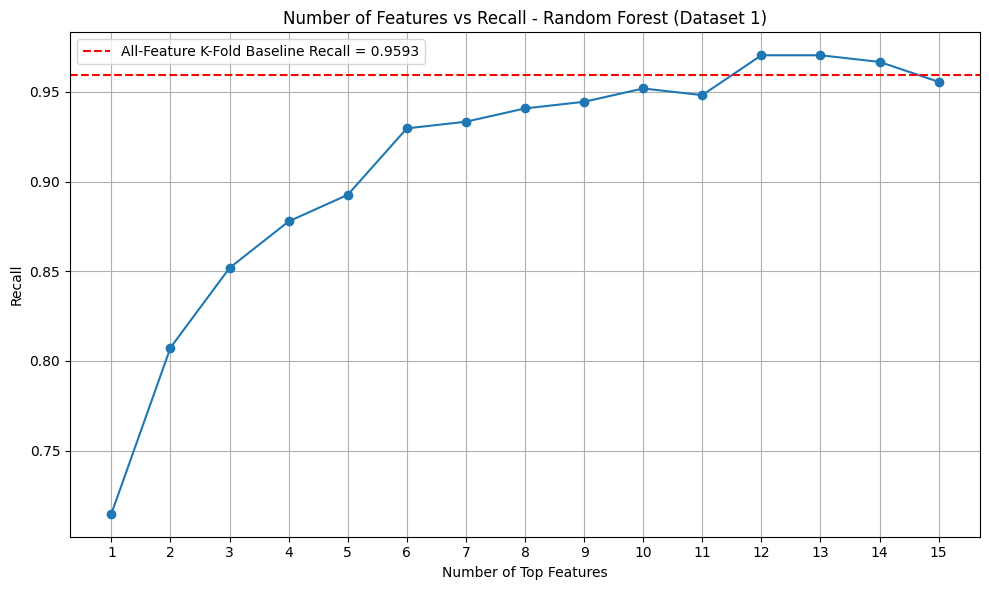

In [12]:
# RANDOM FOREST
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

print("DATASET 1: Lung Cancer Dataset - Random Forest")

pd.set_option('display.max_columns', None)

df1_rf = df_Lung_Cancer.copy()

# Clean column names
df1_rf.columns = df1_rf.columns.str.strip()

print("First 5 rows:")
print(df1_rf.head())

print("\nColumn names:")
print(df1_rf.columns.tolist())

print("\nDataset info:")
df1_rf.info()

print("\nMissing values:")
print(df1_rf.isnull().sum())

# ENCODE CATEGORICAL VARIABLES
label_encoders = {}

for col in df1_rf.columns:
    if df1_rf[col].dtype == "object":
        le = LabelEncoder()
        df1_rf[col] = le.fit_transform(df1_rf[col].astype(str))
        label_encoders[col] = le

# DEFINE TARGET AND FEATURES
target_col = "LUNG_CANCER"
X1_rf = df1_rf.drop(columns=[target_col])
y1_rf = df1_rf[target_col]

print("\nClass distribution:")
print(y1_rf.value_counts())

print("\nClass distribution (proportion):")
print(y1_rf.value_counts(normalize=True))

# ORIGINAL TRAIN-TEST BASELINE
X1_rf_train, X1_rf_test, y1_rf_train, y1_rf_test = train_test_split(
    X1_rf,
    y1_rf,
    test_size=0.2,
    random_state=42,
    stratify=y1_rf
)

rf_model_split = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_split.fit(X1_rf_train, y1_rf_train)
y1_rf_pred = rf_model_split.predict(X1_rf_test)

accuracy_rf = accuracy_score(y1_rf_test, y1_rf_pred)
precision_rf = precision_score(y1_rf_test, y1_rf_pred, zero_division=0)
recall_rf = recall_score(y1_rf_test, y1_rf_pred, zero_division=0)
f1_rf = f1_score(y1_rf_test, y1_rf_pred, zero_division=0)

print("\nRandom Forest Results: Dataset 1 (80/20 Split Baseline)")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")

cm_rf = confusion_matrix(y1_rf_test, y1_rf_pred)

print("\nConfusion Matrix:")
print(cm_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Confusion Matrix - Random Forest (Dataset 1)")
plt.tight_layout()
plt.show()

# K-FOLD BASELINE
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

baseline_rf_cv_results = cross_validate(
    baseline_rf_model,
    X1_rf,
    y1_rf,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_rf_cv = baseline_rf_cv_results["test_accuracy"].mean()
baseline_precision_rf_cv = baseline_rf_cv_results["test_precision"].mean()
baseline_recall_rf_cv = baseline_rf_cv_results["test_recall"].mean()
baseline_f1_rf_cv = baseline_rf_cv_results["test_f1"].mean()

print("\nRandom Forest Results: Dataset 1 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_rf_cv:.4f}")
print(f"Mean Precision: {baseline_precision_rf_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_rf_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_rf_cv:.4f}")

# FEATURE IMPORTANCE
rf_model_full = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_full.fit(X1_rf, y1_rf)

feature_importance_rf_df = pd.DataFrame({
    "Feature": X1_rf.columns,
    "Importance": rf_model_full.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking")
print(feature_importance_rf_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_rf_df, x="Importance", y="Feature")
plt.title("Feature Importance - Random Forest (Dataset 1)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS
individual_feature_rf_results = []

for feature in feature_importance_rf_df["Feature"]:
    X_single_rf = X1_rf[[feature]]

    single_rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    single_rf_cv_results = cross_validate(
        single_rf_model,
        X_single_rf,
        y1_rf,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    individual_feature_rf_results.append({
        "Feature_Set": feature,
        "Num_Features": 1,
        "Accuracy": single_rf_cv_results["test_accuracy"].mean(),
        "Precision": single_rf_cv_results["test_precision"].mean(),
        "Recall": single_rf_cv_results["test_recall"].mean(),
        "F1-score": single_rf_cv_results["test_f1"].mean()
    })

individual_feature_rf_df = pd.DataFrame(individual_feature_rf_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_rf_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS
ranked_rf_features = feature_importance_rf_df["Feature"].tolist()
topk_rf_results = []

for k in range(1, len(ranked_rf_features) + 1):
    selected_rf_features = ranked_rf_features[:k]
    X_topk_rf = X1_rf[selected_rf_features]

    topk_rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    topk_rf_cv_results = cross_validate(
        topk_rf_model,
        X_topk_rf,
        y1_rf,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_rf_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_rf_features),
        "Accuracy": topk_rf_cv_results["test_accuracy"].mean(),
        "Precision": topk_rf_cv_results["test_precision"].mean(),
        "Recall": topk_rf_cv_results["test_recall"].mean(),
        "F1-score": topk_rf_cv_results["test_f1"].mean()
    })

topk_rf_results_df = pd.DataFrame(topk_rf_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_rf_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_rf_row = pd.DataFrame([{
    "Num_Features": X1_rf.shape[1],
    "Features_Used": "All Features (Official Baseline)",
    "Accuracy": baseline_accuracy_rf_cv,
    "Precision": baseline_precision_rf_cv,
    "Recall": baseline_recall_rf_cv,
    "F1-score": baseline_f1_rf_cv
}])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_rf_row)

# PLOT: NUMBER OF FEATURES VS RECALL
plt.figure(figsize=(10, 6))
plt.plot(topk_rf_results_df["Num_Features"], topk_rf_results_df["Recall"], marker="o")
plt.axhline(
    y=baseline_recall_rf_cv,
    color="red",
    linestyle="--",
    label=f"All-Feature K-Fold Baseline Recall = {baseline_recall_rf_cv:.4f}"
)
plt.title("Number of Features vs Recall - Random Forest (Dataset 1)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_rf_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# RANDOM FOREST RESULTS FOR FINAL COMPARISON
rf_summary = {
    "Model": "Random Forest",
    "Accuracy": accuracy_rf,
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1-score": f1_rf,
    "CV Accuracy": baseline_accuracy_rf_cv,
    "CV Precision": baseline_precision_rf_cv,
    "CV Recall": baseline_recall_rf_cv,
    "CV F1-score": baseline_f1_rf_cv
}

cm_rf_saved = cm_rf.copy()
topk_rf_results_df = topk_rf_results_df.copy()